In [2]:
!pip install Pillow opencv-python numpy pandas matplotlib plotly seaborn tensorflow scikit-learn

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/40.2 MB 9.9 MB/s eta 0:00:04
   ----- ---------------------------------- 5.8/40.2 MB 17.2 MB/s eta 0:00:03
   ---------- ----------------------------- 10.5/40.2 MB 19.0 MB/s eta 0:00:02
   ------------- -------------------------- 13.9/40.2 MB 18.4 MB/s eta 0:00:02
   ---------------- ----------------------- 17.0/40.2 MB 17.9 MB/s eta 0:00:02
   ------------------ ----------------

In [3]:
#importing libraries
import os
from PIL import Image
import itertools

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set_style('darkgrid')

import warnings
warnings.filterwarnings('ignore')


import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense, Activation, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [16]:
# Loading Data
train_data = r"C:\Users\Student\Desktop\lab\chest_xray\train"
valid_data = r"c:\Users\Student\Desktop\lab\chest_xray\val"
test_data = r"c:\Users\Student\Desktop\lab\chest_xray\test"

In [18]:
#Preprocessing Train Dataset

training_generator = ImageDataGenerator(rescale = 1/255)

filepaths = []
labels = []

folds = os.listdir(train_data)
for fold in folds:
    foldpath = os.path.join(train_data, fold)
    if not os.path.isdir(foldpath):
       continue
    filelist = os.listdir(foldpath)

    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

FSeries = pd.Series(filepaths, name='filepaths')
LSeries = pd.Series(labels, name='label')

df = pd.concat([FSeries, LSeries], axis=1)


df

,filepaths,label
0,C:\Users\Student\Desktop\lab\chest_xray\train\...,NORMAL
1,C:\Users\Student\Desktop\lab\chest_xray\train\...,NORMAL
2,C:\Users\Student\Desktop\lab\chest_xray\train\...,NORMAL
3,C:\Users\Student\Desktop\lab\chest_xray\train\...,NORMAL
4,C:\Users\Student\Desktop\lab\chest_xray\train\...,NORMAL
...,...,...
5213,C:\Users\Student\Desktop\lab\chest_xray\train\...,PNEUMONIA
5214,C:\Users\Student\Desktop\lab\chest_xray\train\...,PNEUMONIA
5215,C:\Users\Student\Desktop\lab\chest_xray\train\...,PNEUMONIA
5216,C:\Users\Student\Desktop\lab\chest_xray\train\...,PNEUMONIA


In [20]:
#Preprocessing Valid Dataset

validation_generator = ImageDataGenerator(rescale = 1/255)

filepaths = []
labels = []

folds = os.listdir(valid_data)
for fold in folds:
    foldpath = os.path.join(valid_data, fold)
    if not os.path.isdir(foldpath):
      continue
    filelist = os.listdir(foldpath)

    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

FSeries = pd.Series(filepaths, name='filepaths')
LSeries = pd.Series(labels, name='label')

valid = pd.concat([FSeries, LSeries], axis=1)

valid

,filepaths,label
0,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
1,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
2,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
3,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
4,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
5,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
6,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
7,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
8,c:\Users\Student\Desktop\lab\chest_xray\val\NO...,NORMAL
9,c:\Users\Student\Desktop\lab\chest_xray\val\PN...,PNEUMONIA


In [22]:
#Preprocessing Test Dataset
testing_generator = ImageDataGenerator(rescale = 1/255)

test_data = "chest_xray/test"
filepaths = []
labels = []

folds = os.listdir(test_data)

for fold in folds:
    foldpath = os.path.join(test_data, fold)
    if not os.path.isdir(foldpath):
        continue
    filelist = os.listdir(foldpath)

    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

FSeries = pd.Series(filepaths, name='filepaths')
LSeries = pd.Series(labels, name='label')

test = pd.concat([FSeries, LSeries], axis=1)

test

,filepaths,label
0,chest_xray/test\NORMAL\IM-0001-0001.jpeg,NORMAL
1,chest_xray/test\NORMAL\IM-0003-0001.jpeg,NORMAL
2,chest_xray/test\NORMAL\IM-0005-0001.jpeg,NORMAL
3,chest_xray/test\NORMAL\IM-0006-0001.jpeg,NORMAL
4,chest_xray/test\NORMAL\IM-0007-0001.jpeg,NORMAL
...,...,...
619,chest_xray/test\PNEUMONIA\person96_bacteria_46...,PNEUMONIA
620,chest_xray/test\PNEUMONIA\person96_bacteria_46...,PNEUMONIA
621,chest_xray/test\PNEUMONIA\person97_bacteria_46...,PNEUMONIA
622,chest_xray/test\PNEUMONIA\person99_bacteria_47...,PNEUMONIA


In [23]:
#Spliting Data Into Train, Valid, Test

train_df, dummy_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=42)
valid_df, test_df = train_test_split(dummy_df, train_size=0.5, shuffle=True, random_state=42)



In [24]:
#ImageDataGenerator

# crobed image size
batch_size = 16
img_size = (224, 224)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()
val_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = val_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'label', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 4172 validated image filenames belonging to 2 classes.
Found 522 validated image filenames belonging to 2 classes.
Found 522 validated image filenames belonging to 2 classes.


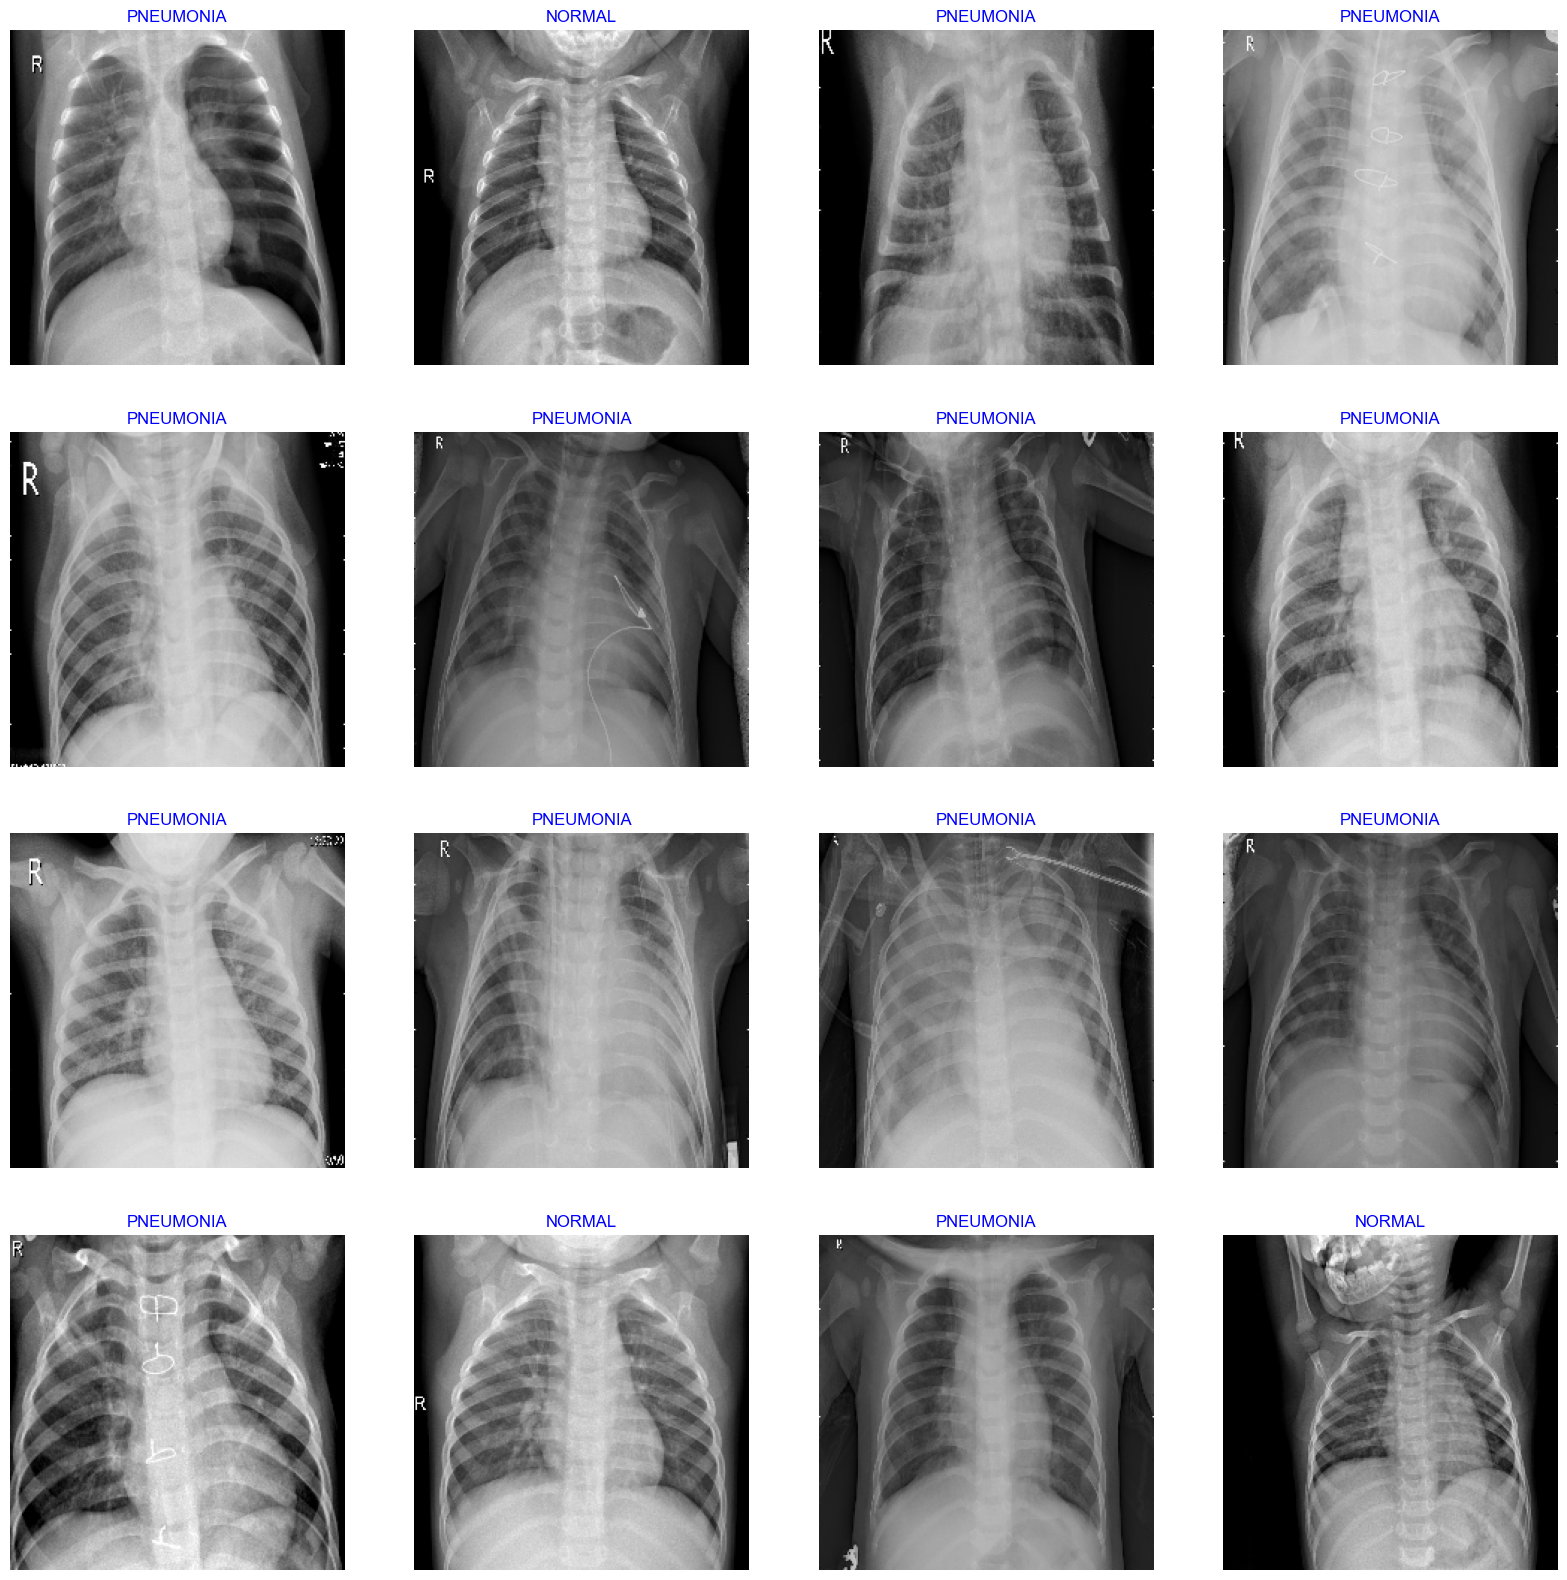

In [25]:
# Data Sample Visualization

gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images , labels = next(train_gen)

plt.figure(figsize= (20,20))

for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name , color = 'blue' , fontsize= 12)
    plt.axis('off')
plt.show();

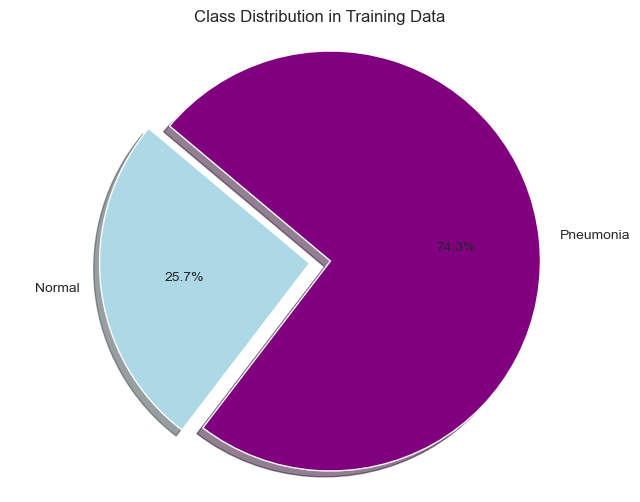

In [26]:
# Initialize counters for each class
normal_count = 0
pneumonia_count = 0

# Loop through each class directory and count the number of samples
for class_name in os.listdir(train_data):
    class_path = os.path.join(train_data, class_name)
    if os.path.isdir(class_path):
        if class_name.lower() == "normal":
            normal_count += len(os.listdir(class_path))
        elif class_name.lower() == "pneumonia":
            pneumonia_count += len(os.listdir(class_path))

# Create labels and counts for the pie chart
labels = ['Normal', 'Pneumonia']
sizes = [normal_count, pneumonia_count]
colors = ['lightblue', '#800080']
explode = (0, 0.1)  # explode the 2nd slice (i.e., 'Pneumonia')
template='plotly_dark',

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Class Distribution in Training Data')
plt.show()

In [27]:
# Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

model = Sequential([
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu", input_shape= img_shape),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(256,activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(class_count, activation = "softmax")
])

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,154,050 (80.70 MB)

 Trainable params: 21,154,050 (80.70 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Training The Data

epochs = 6   # number of all epochs in training

history = model.fit(train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/6
261/261 ━━━━━━━━━━━━━━━━━━━━ 823s 3s/step - accuracy: 0.8099 - loss: 2.4373 - val_accuracy: 0.8659 - val_loss: 0.3239
Epoch 2/6
261/261 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.9406 - loss: 0.1598 - val_accuracy: 0.9100 - val_loss: 0.1840
Epoch 3/6
261/261 ━━━━━━━━━━━━━━━━━━━━ 614s 2s/step - accuracy: 0.9664 - loss: 0.0971 - val_accuracy: 0.9387 - val_loss: 0.1506
Epoch 4/6
261/261 ━━━━━━━━━━━━━━━━━━━━ 592s 2s/step - accuracy: 0.9758 - loss: 0.0716 - val_accuracy: 0.9502 - val_loss: 0.1495
Epoch 5/6
261/261 ━━━━━━━━━━━━━━━━━━━━ 598s 2s/step - accuracy: 0.9744 - loss: 0.0608 - val_accuracy: 0.9559 - val_loss: 0.1125
Epoch 6/6
261/261 ━━━━━━━━━━━━━━━━━━━━ 609s 2s/step - accuracy: 0.9823 - loss: 0.0572 - val_accuracy: 0.9291 - val_loss: 0.2144


In [29]:
train_score = model.evaluate(train_gen, verbose= 1)
valid_score = model.evaluate(valid_gen, verbose= 1)
test_score = model.evaluate(test_gen, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

261/261 ━━━━━━━━━━━━━━━━━━━━ 143s 547ms/step - accuracy: 0.9679 - loss: 0.0987
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 542ms/step - accuracy: 0.9291 - loss: 0.2144
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 541ms/step - accuracy: 0.9425 - loss: 0.2779
Train Loss:  0.0986839085817337
Train Accuracy:  0.9678810834884644
--------------------
Validation Loss:  0.21440425515174866
Validation Accuracy:  0.9291187524795532
--------------------
Test Loss:  0.2779351472854614
Test Accuracy:  0.9425287246704102


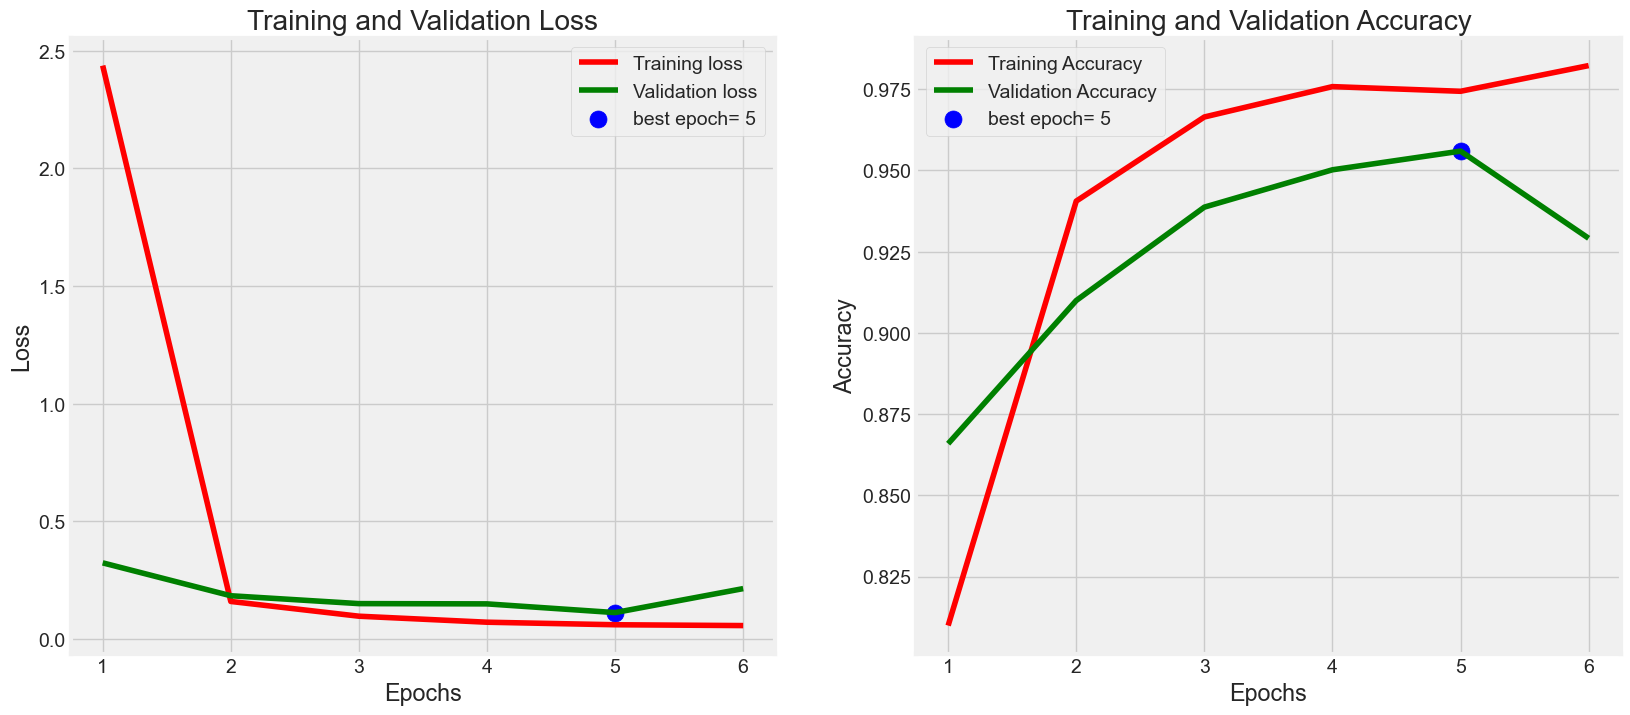

In [30]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [31]:
# Use the predict method directly on your model
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 496ms/step


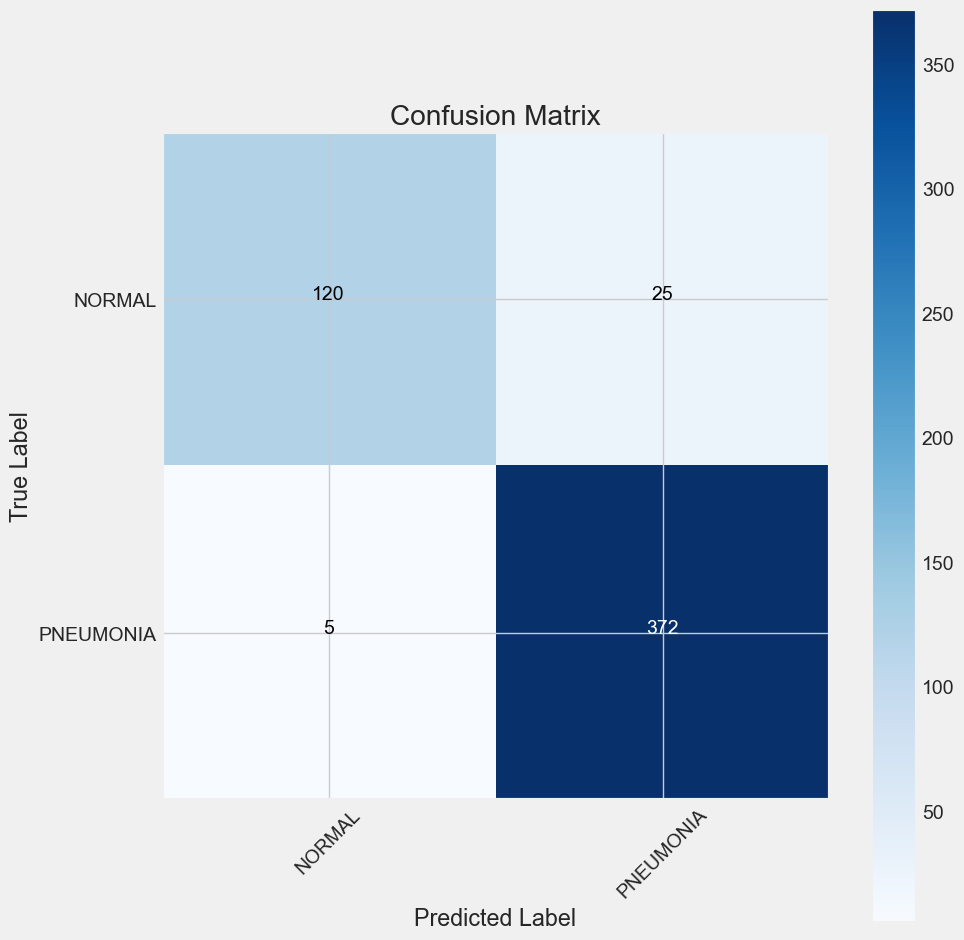

In [32]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)
cm

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [33]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

      NORMAL       0.96      0.83      0.89       145
   PNEUMONIA       0.94      0.99      0.96       377

    accuracy                           0.94       522
   macro avg       0.95      0.91      0.93       522
weighted avg       0.94      0.94      0.94       522



## unseen

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

img_size = (224, 224)

def predict_image(img_path):
    # load image
    img = load_img(img_path, target_size=img_size)
    arr = img_to_array(img)

    # IMPORTANT: same scaling as training
    arr = arr / 255.0

    # add batch dimension
    arr = np.expand_dims(arr, axis=0)

    # predict
    pred = model.predict(arr, verbose=0)[0]
    pred_index = np.argmax(pred)

    # class name
    classes = list(train_gen.class_indices.keys())
    predicted_class = classes[pred_index]
    confidence = pred[pred_index]

    return predicted_class, confidence


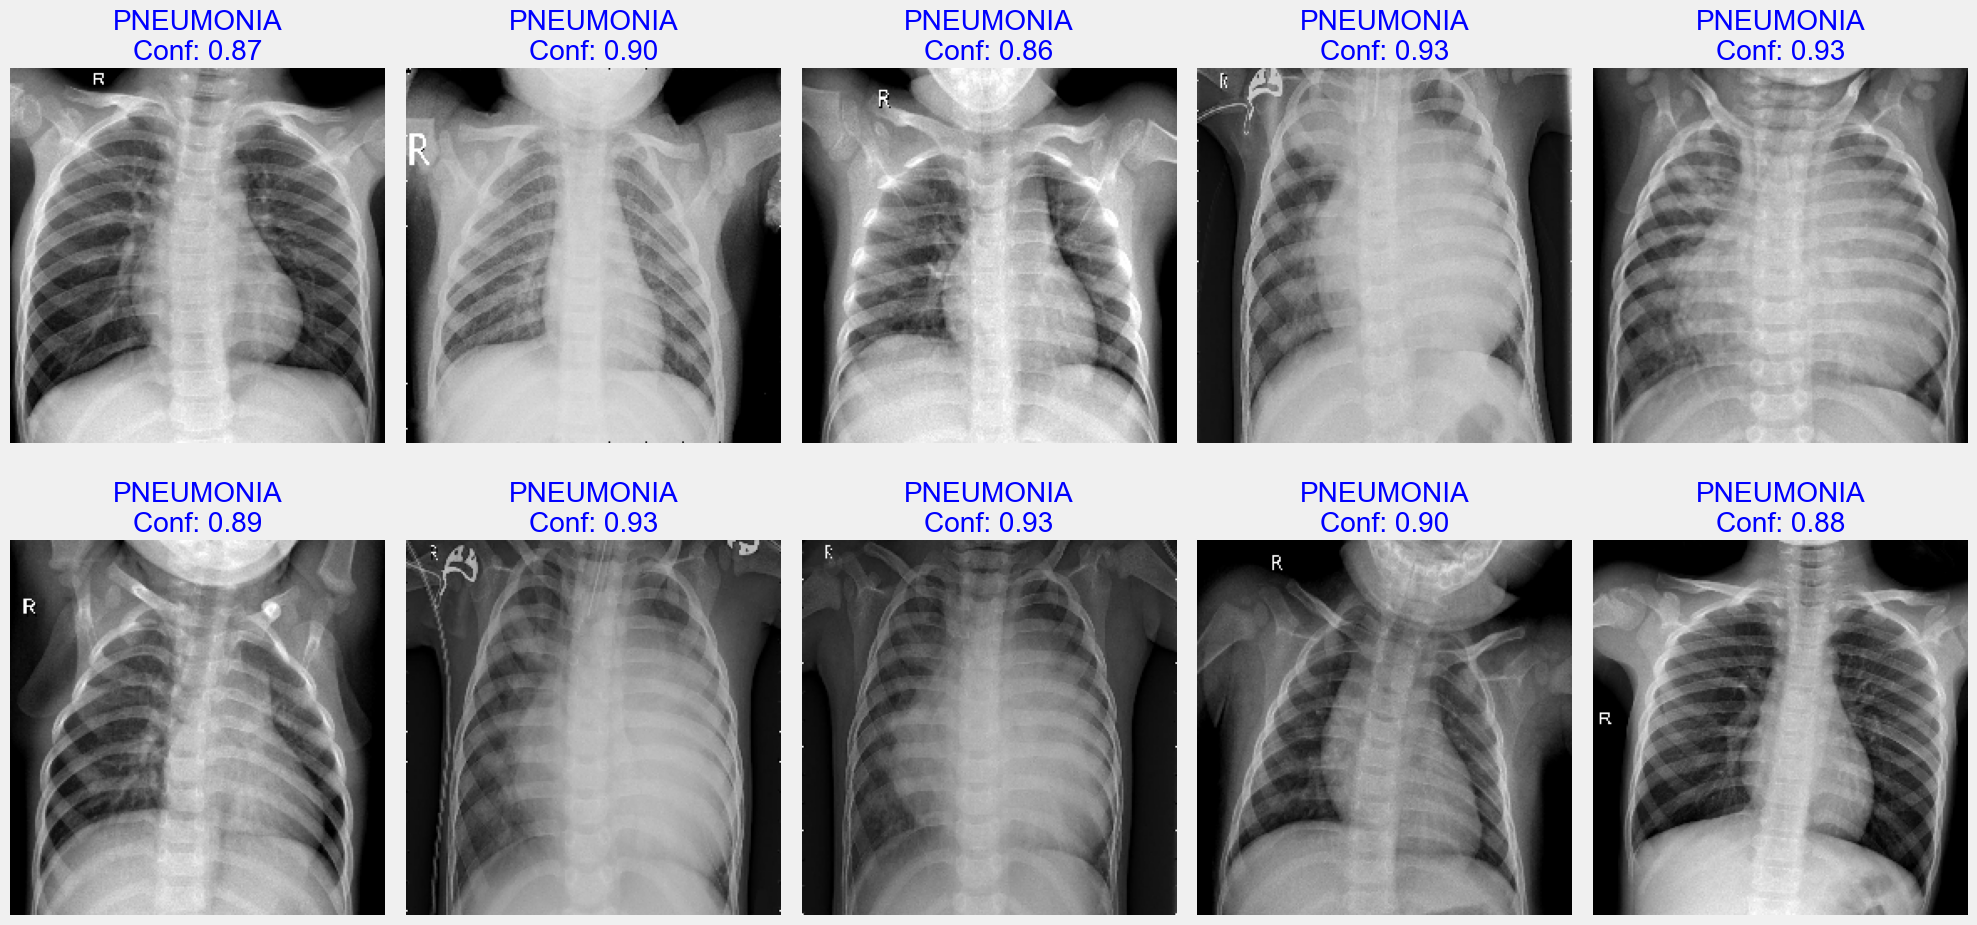

In [41]:

unseen_dir = r"C:\Users\Student\Desktop\lab\letscheck"   # change path
image_files = [f for f in os.listdir(unseen_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))]

# pick 10 random images
np.random.shuffle(image_files)
image_files = image_files[:10]

plt.figure(figsize=(20, 10))

for i, file in enumerate(image_files):
    path = os.path.join(unseen_dir, file)

    pred_class, conf = predict_image(path)

    # show image
    plt.subplot(2, 5, i+1)
    img = load_img(path, target_size=img_size)
    plt.imshow(img)
    plt.title(f"{pred_class}\nConf: {conf:.2f}", color="blue")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [37]:
from sklearn.metrics import classification_report, confusion_matrix

unseen_gen = ImageDataGenerator(rescale=1/255).flow_from_directory(
    unseen_dir,
    target_size=img_size,
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

preds = model.predict(unseen_gen)
y_pred = np.argmax(preds, axis=1)
y_true = unseen_gen.classes

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=list(unseen_gen.class_indices.keys())))


Found 0 images belonging to 0 classes.


ValueError: The PyDataset has length 0